In [1]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder, StandardScaler,MinMaxScaler

In [2]:
data = pd.read_csv("cleaned_air_quality_data.csv")
df = pd.read_csv("cleaned_air_quality_data.csv")

In [4]:
df.head()

,City,Datetime,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
0,Amaravati,2017-11-25 09:00:00,104.00,148.50,1.93,23.00,13.75,9.80,0.1,15.30,117.62,0.30,10.40,0.23,155.0,Moderate
1,Amaravati,2017-11-25 10:00:00,94.50,142.00,1.33,16.25,9.75,9.65,0.1,17.00,136.23,0.28,7.10,0.15,159.0,Moderate
2,Amaravati,2017-11-25 11:00:00,82.75,126.50,1.47,14.83,9.07,9.70,0.1,15.40,149.92,0.20,4.55,0.08,173.0,Moderate
3,Amaravati,2017-11-25 14:00:00,68.50,117.00,1.35,13.60,8.35,7.40,0.1,21.80,161.70,0.10,2.30,0.00,191.0,Moderate
4,Amaravati,2017-11-25 15:00:00,69.25,112.25,1.52,11.80,7.55,9.25,0.1,21.38,161.68,0.10,2.35,0.00,191.0,Moderate


In [5]:
df.shape

(135513, 16)

In [5]:
data.describe()

,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI
count,135513.000000,135513.000000,135513.000000,135513.000000,135513.000000,135513.000000,135513.000000,135513.000000,135513.000000,135513.000000,135513.000000,135513.000000,135513.000000
mean,63.801550,128.056047,18.058426,32.764881,34.143929,21.770282,1.028805,11.292169,36.341758,3.902369,11.297990,2.566186,145.180580
std,61.791613,98.798951,28.636281,22.858898,34.984655,18.016488,1.563338,10.228842,27.366368,5.824344,14.928082,5.311568,96.823667
min,0.030000,1.000000,0.010000,0.100000,0.000000,0.010000,0.000000,0.010000,0.020000,0.000000,0.000000,0.000000,18.000000
25%,27.000000,63.940000,3.620000,15.450000,13.470000,10.330000,0.440000,5.550000,17.000000,0.940000,2.340000,0.230000,79.000000
50%,47.500000,101.520000,8.330000,27.270000,23.050000,15.320000,0.700000,8.890000,28.500000,2.250000,6.210000,1.010000,114.000000
75%,76.380000,157.020000,17.910000,44.060000,40.160000,29.500000,1.070000,13.650000,48.380000,4.560000,13.900000,2.710000,176.000000
max,999.990000,1000.000000,419.780000,266.730000,408.250000,485.520000,31.620000,199.930000,219.780000,120.080000,198.050000,261.950000,760.000000


In [6]:
data.isnull().sum()

City          0
Datetime      0
PM2.5         0
PM10          0
NO            0
NO2           0
NOx           0
NH3           0
CO            0
SO2           0
O3            0
Benzene       0
Toluene       0
Xylene        0
AQI           0
AQI_Bucket    0
dtype: int64

In [7]:
data.duplicated().sum()

np.int64(0)

**Data Preprocessing**

Check duplicates in dataset

In [8]:
num_duplicates = df.duplicated().sum()

print("--- Duplicate Row Analysis ---")
print(f"Found {num_duplicates} duplicate rows in the dataset.")
print("-" * 40 + "\n")

--- Duplicate Row Analysis ---
Found 0 duplicate rows in the dataset.
----------------------------------------



Check for Null Values in Each Column

In [9]:
null_counts = df.isnull().sum()

print("--- Null Value Analysis ---")
print("Number of null (missing) values in each column:")
print(null_counts[null_counts > 0])
print("-" * 40 + "\n")


--- Null Value Analysis ---
Number of null (missing) values in each column:
Series([], dtype: int64)
----------------------------------------



Check for Infinite Values in Each Column

In [10]:
import numpy as np

is_pos_inf = df.isin([np.inf])
is_neg_inf = df.isin([-np.inf])

pos_inf_counts = is_pos_inf.sum()
neg_inf_counts = is_neg_inf.sum()

print("--- Infinite Value Analysis ---")


--- Infinite Value Analysis ---


In [11]:
print("Columns with positive infinite values:")
print(pos_inf_counts[pos_inf_counts > 0])

print("\nColumns with negative infinite values:")
print(neg_inf_counts[neg_inf_counts > 0])
print("-" * 40 + "\n")

Columns with positive infinite values:
Series([], dtype: int64)

Columns with negative infinite values:
Series([], dtype: int64)
----------------------------------------



Check Outliers in dataset

In [12]:
import pandas as pd

numerical_cols = df.select_dtypes(include=['number']).columns

Q1 = df[numerical_cols].quantile(0.25)
Q3 = df[numerical_cols].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

In [13]:
print("--- Outlier Analysis Report ---")
print("Checking each numerical column for values outside the 1.5 * IQR range...\n")
total_outliers_found = 0

for col in numerical_cols:
    outlier_mask = (df[col] < lower_bound[col]) | (df[col] > upper_bound[col])

    num_outliers = outlier_mask.sum()

    if num_outliers > 0:
        print(f"Column '{col}': Found {num_outliers} outliers.")
        total_outliers_found += num_outliers

if total_outliers_found == 0:
    print("No outliers were found in any column.")

print("\n" + "-"*40 + "\n")

--- Outlier Analysis Report ---
Checking each numerical column for values outside the 1.5 * IQR range...

Column 'PM2.5': Found 9875 outliers.
Column 'PM10': Found 9067 outliers.
Column 'NO': Found 15607 outliers.
Column 'NO2': Found 4021 outliers.
Column 'NOx': Found 11605 outliers.
Column 'NH3': Found 5120 outliers.
Column 'CO': Found 9801 outliers.
Column 'SO2': Found 7836 outliers.
Column 'O3': Found 6039 outliers.
Column 'Benzene': Found 10292 outliers.
Column 'Toluene': Found 11489 outliers.
Column 'Xylene': Found 13509 outliers.
Column 'AQI': Found 10047 outliers.

----------------------------------------



In [14]:
# Remove All Rows Containing Any Outliers ---
final_outlier_mask = ((df[numerical_cols] < lower_bound) | (df[numerical_cols] > upper_bound)).any(axis=1)

df_no_outliers = df[~final_outlier_mask]

In [15]:
print("--- Data Cleaning Summary ---")
print(f"Shape before removing outliers: {df.shape}")
print(f"Shape after removing outliers: {df_no_outliers.shape}")
print(f"Total number of outlier rows removed: {df.shape[0] - df_no_outliers.shape[0]}")

--- Data Cleaning Summary ---
Shape before removing outliers: (135513, 16)
Shape after removing outliers: (81996, 16)
Total number of outlier rows removed: 53517


In [16]:
df_no_outliers.drop('Datetime', axis=1, inplace=True)

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_10088\496743994.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_no_outliers.drop('Datetime', axis=1, inplace=True)


Numpy Array

In [17]:
feature_columns = [
    'City', 'PM2.5', 'PM10', 'NO', 'NO2', 'NOx',
    'NH3', 'CO', 'SO2', 'O3', 'Benzene', 'Toluene',
    'Xylene', 'AQI'
]
X = df_no_outliers[feature_columns]
y = df_no_outliers['AQI_Bucket']
X = df_no_outliers.drop(['AQI_Bucket'], axis=1)
print("Features (X):")
print(X.head())
print("\nTarget (y):")
print(y.head())

Features (X):
         City   PM2.5    PM10    NO    NO2    NOx    NH3    CO    SO2     O3  \
19  Amaravati   98.25  137.75  0.38  31.75  17.18   9.00  0.10  12.12  89.20   
20  Amaravati  103.00  144.75  1.37  40.50  22.70   9.67  0.10  10.42  36.75   
21  Amaravati   97.75  143.00  2.00  38.48  22.12  10.73  0.10  16.12  92.12   
33  Amaravati   80.00  159.50  3.97  41.65  25.40  11.25  0.18  12.47  70.07   
34  Amaravati   84.00  160.00  0.73  48.07  26.20  11.20  0.50  12.10  56.85   

    Benzene  Toluene  Xylene    AQI  
19     0.33    14.33    0.10  186.0  
20     0.30    12.40    0.10  189.0  
21     0.30    11.03    0.15  191.0  
33     0.30     9.22    0.10  181.0  
34     0.28     9.58    0.10  181.0  

Target (y):
19    Moderate
20    Moderate
21    Moderate
33    Moderate
34    Moderate
Name: AQI_Bucket, dtype: object


Label Encoding of data

In [18]:
from sklearn.preprocessing import LabelEncoder
import pandas as pd

In [19]:
label_encoders_X = {}

for col in X.select_dtypes(include='object').columns:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])
    label_encoders_X[col] = le

In [20]:
if y.dtype == 'object' or y.dtype.name == 'category':
    le_y = LabelEncoder()
    y = le_y.fit_transform(y)
else:
    le_y = None

In [21]:
print("Encoded Features (X):")
print(X.head())

print("\nEncoded Target (y):")
print(y[:5])

Encoded Features (X):
    City   PM2.5    PM10    NO    NO2    NOx    NH3    CO    SO2     O3  \
19     0   98.25  137.75  0.38  31.75  17.18   9.00  0.10  12.12  89.20   
20     0  103.00  144.75  1.37  40.50  22.70   9.67  0.10  10.42  36.75   
21     0   97.75  143.00  2.00  38.48  22.12  10.73  0.10  16.12  92.12   
33     0   80.00  159.50  3.97  41.65  25.40  11.25  0.18  12.47  70.07   
34     0   84.00  160.00  0.73  48.07  26.20  11.20  0.50  12.10  56.85   

    Benzene  Toluene  Xylene    AQI  
19     0.33    14.33    0.10  186.0  
20     0.30    12.40    0.10  189.0  
21     0.30    11.03    0.15  191.0  
33     0.30     9.22    0.10  181.0  
34     0.28     9.58    0.10  181.0  

Encoded Target (y):
[1 1 1 1 1]


Scalling of features data

In [22]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Split test and train data

In [23]:
from sklearn.model_selection import train_test_split

In [24]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

print(f"X_train: {X_train.shape}")
print(f"X_test: {X_test.shape}")
print(f"y_train: {y_train.shape}")
print(f"y_test: {y_test.shape}")

X_train: (65596, 14)
X_test: (16400, 14)
y_train: (65596,)
y_test: (16400,)


Logistic regression

In [25]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [26]:
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [27]:
y_pred = log_reg.predict(X_test)

In [28]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.9945731707317074
Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.99      0.99      1782
           1       1.00      1.00      1.00      6538
           2       0.99      0.98      0.99      1124
           3       1.00      1.00      1.00      6793
           4       0.94      0.99      0.96       163

    accuracy                           0.99     16400
   macro avg       0.98      0.99      0.99     16400
weighted avg       0.99      0.99      0.99     16400



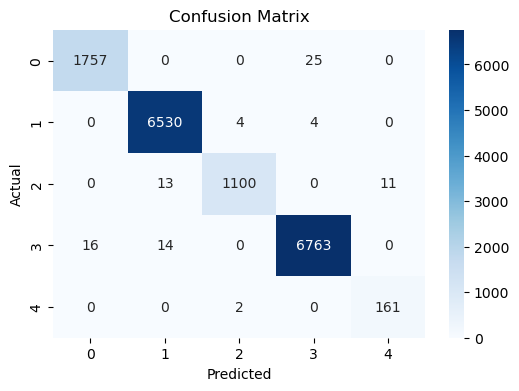

In [29]:
#Confusion matrix
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [30]:
import numpy as np

new_data = {
    'City': 'Amaravati',
    'PM2.5': 104,
    'PM10': 148.5,
    'NO': 1.93,
    'NO2': 23,
    'NOx': 13.75,
    'NH3': 9.8,
    'CO': 0.1,
    'SO2': 15.3,
    'O3': 117.62,
    'Benzene': 0.3,
    'Toluene': 10.4,
    'Xylene': 0.23,
    'AQI': 155
}

input_df = pd.DataFrame([new_data])

# Encode categorical columns (like 'City')
for col in input_df.select_dtypes(include='object').columns:
    if col in label_encoders_X:
        input_df[col] = label_encoders_X[col].transform(input_df[col])
    else:
        raise ValueError(f"Encoder for column '{col}' not found.")

# Scale the input using the same scaler
input_scaled = scaler.transform(input_df)

# Predict using the trained model
pred_encoded = log_reg.predict(input_scaled)

# Decode prediction if target was label encoded
if le_y:
    prediction = le_y.inverse_transform(pred_encoded)[0]
else:
    prediction = pred_encoded[0]

print(f"Predicted AQI Bucket: {prediction}")


Predicted AQI Bucket: Moderate


Decision Tree

In [31]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

In [32]:
dt_model = DecisionTreeClassifier(max_depth=5, random_state=42)
dt_model.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [33]:
y_pred_dt = dt_model.predict(X_test)

In [34]:
print("Accuracy (Decision Tree):", accuracy_score(y_test, y_pred_dt))
print("\nClassification Report:\n", classification_report(y_test, y_pred_dt))

Accuracy (Decision Tree): 1.0

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      1782
           1       1.00      1.00      1.00      6538
           2       1.00      1.00      1.00      1124
           3       1.00      1.00      1.00      6793
           4       1.00      1.00      1.00       163

    accuracy                           1.00     16400
   macro avg       1.00      1.00      1.00     16400
weighted avg       1.00      1.00      1.00     16400



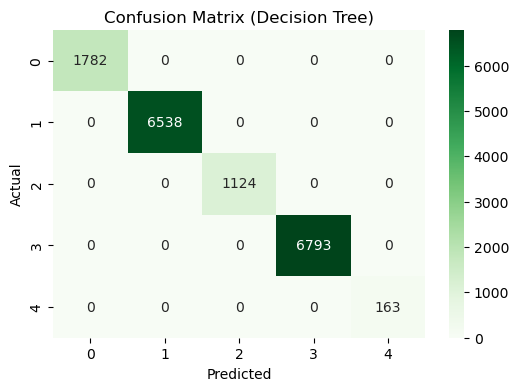

In [35]:
#Confusion Matrix
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_pred_dt), annot=True, fmt="d", cmap="Greens")
plt.title("Confusion Matrix (Decision Tree)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

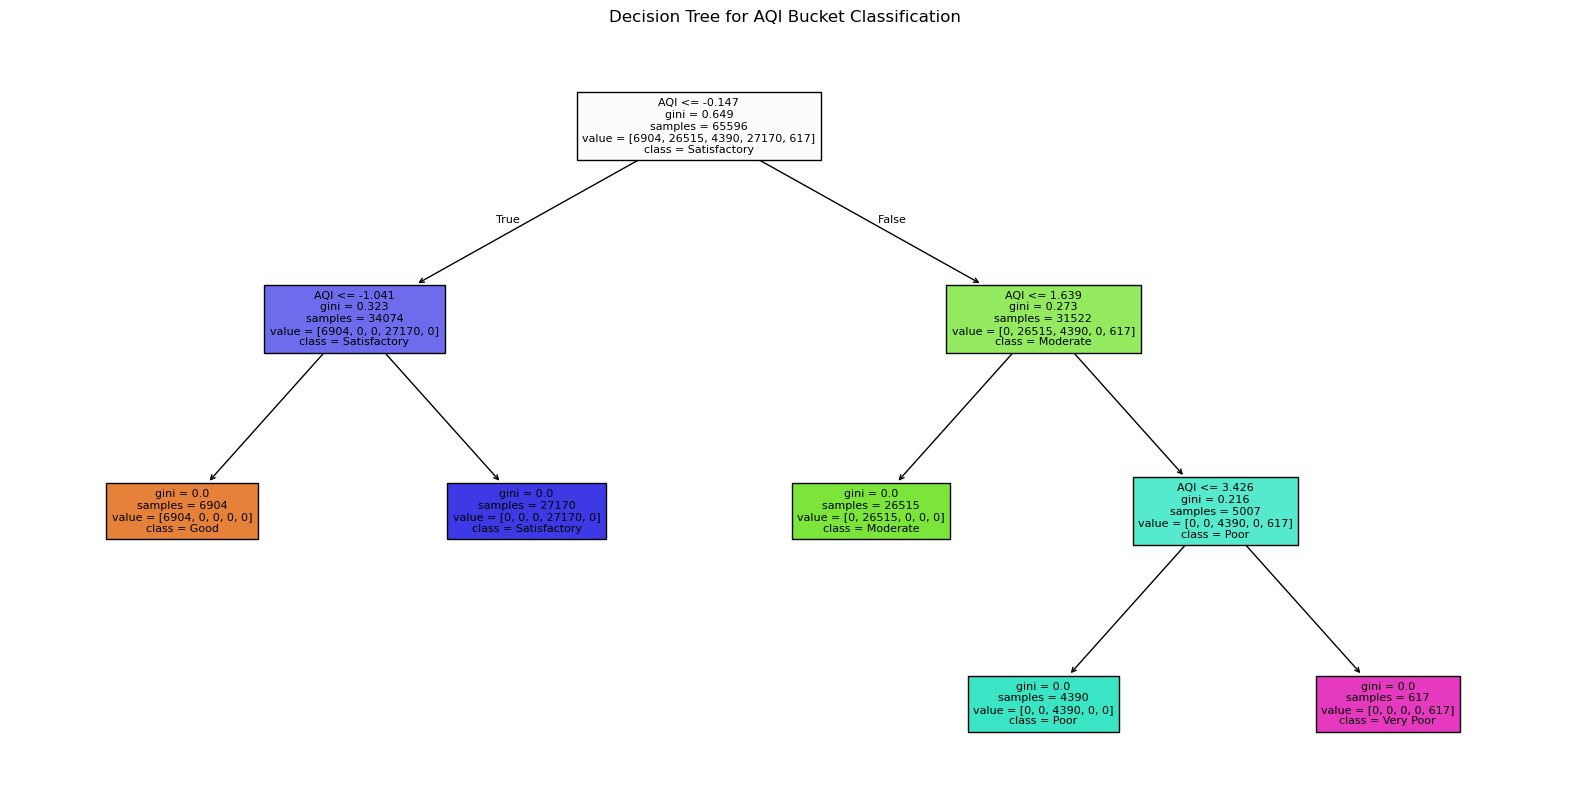

In [36]:
#Visualize the Decision Tree
plt.figure(figsize=(20, 10))
plot_tree(dt_model, feature_names=X.columns, class_names=le_y.classes_, filled=True, fontsize=8)
plt.title("Decision Tree for AQI Bucket Classification")
plt.show()

Random Forest

In [37]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

In [38]:
#Train the model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [39]:
y_pred_rf = rf_model.predict(X_test)

In [40]:
print("Accuracy (Random Forest):", accuracy_score(y_test, y_pred_rf))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))

Accuracy (Random Forest): 0.999939024390244

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      1782
           1       1.00      1.00      1.00      6538
           2       1.00      1.00      1.00      1124
           3       1.00      1.00      1.00      6793
           4       1.00      0.99      1.00       163

    accuracy                           1.00     16400
   macro avg       1.00      1.00      1.00     16400
weighted avg       1.00      1.00      1.00     16400



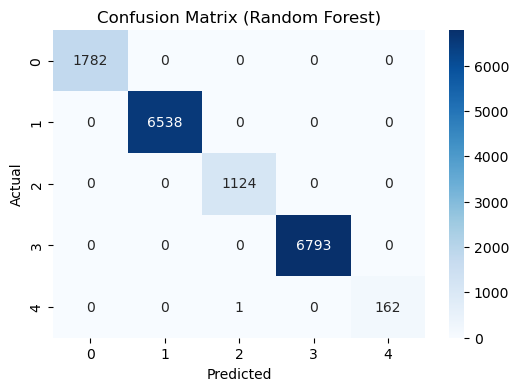

In [41]:
#Confusion Matrix
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix (Random Forest)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


Gradient Boosting

In [42]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

In [43]:

gb_model = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
gb_model.fit(X_train, y_train)

,loss,'log_loss'
,learning_rate,0.1
,n_estimators,100
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


In [44]:
y_pred_gb = gb_model.predict(X_test)

print("Accuracy (Gradient Boosting):", accuracy_score(y_test, y_pred_gb))
print("\n Classification Report:\n", classification_report(y_test, y_pred_gb))

Accuracy (Gradient Boosting): 1.0

 Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      1782
           1       1.00      1.00      1.00      6538
           2       1.00      1.00      1.00      1124
           3       1.00      1.00      1.00      6793
           4       1.00      1.00      1.00       163

    accuracy                           1.00     16400
   macro avg       1.00      1.00      1.00     16400
weighted avg       1.00      1.00      1.00     16400



XGboost and XAI(SHAP)

KNN

In [51]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

In [52]:
knn_model = KNeighborsClassifier(n_neighbors=5)  # You can tune k later
knn_model.fit(X_train, y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [53]:
y_pred_knn = knn_model.predict(X_test)

Accuracy (KNN): 0.8843292682926829

Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.82      0.84      1782
           1       0.90      0.91      0.91      6538
           2       0.86      0.84      0.85      1124
           3       0.88      0.89      0.89      6793
           4       0.76      0.52      0.62       163

    accuracy                           0.88     16400
   macro avg       0.85      0.80      0.82     16400
weighted avg       0.88      0.88      0.88     16400



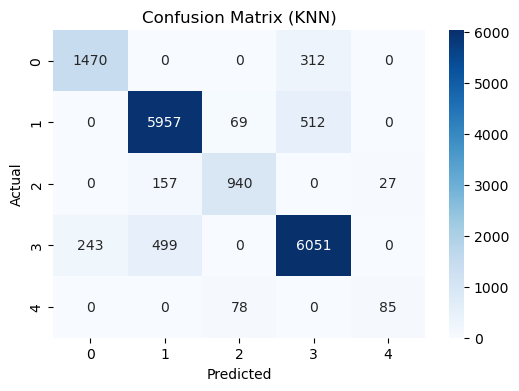

In [54]:
print("Accuracy (KNN):", accuracy_score(y_test, y_pred_knn))
print("\nClassification Report:\n", classification_report(y_test, y_pred_knn))

#Confusion Matrix
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_knn), annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix (KNN)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

SVM

In [55]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

In [56]:
svm_model = SVC(kernel='poly', C=1.0, gamma='scale')  # You can change kernel to 'linear' or 'poly' too
svm_model.fit(X_train, y_train)

,C,1.0
,kernel,'poly'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [57]:
y_pred_svm = svm_model.predict(X_test)

Accuracy (SVM): 0.9613414634146341

Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.92      0.94      1782
           1       0.97      0.97      0.97      6538
           2       0.96      0.96      0.96      1124
           3       0.96      0.96      0.96      6793
           4       0.89      0.92      0.90       163

    accuracy                           0.96     16400
   macro avg       0.95      0.95      0.95     16400
weighted avg       0.96      0.96      0.96     16400



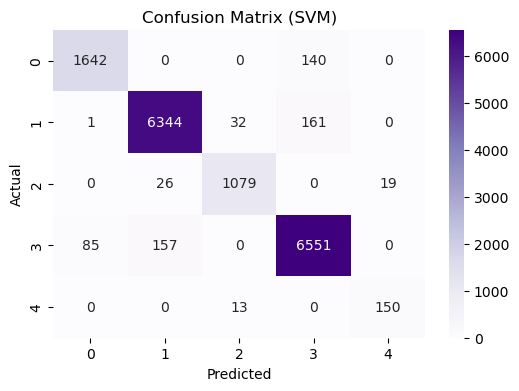

In [58]:
print("Accuracy (SVM):", accuracy_score(y_test, y_pred_svm))
print("\nClassification Report:\n", classification_report(y_test, y_pred_svm))

# Confusion Matrix
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_svm), annot=True, fmt="d", cmap="Purples")
plt.title("Confusion Matrix (SVM)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

NAIVE  Bayes

In [59]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

In [60]:
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)

,priors,None
,var_smoothing,1e-09


Accuracy (Naive Bayes): 0.8374390243902439

Classification Report:
               precision    recall  f1-score   support

           0       0.72      0.89      0.80      1782
           1       0.87      0.85      0.86      6538
           2       0.77      0.89      0.82      1124
           3       0.86      0.80      0.83      6793
           4       0.90      0.96      0.93       163

    accuracy                           0.84     16400
   macro avg       0.82      0.88      0.85     16400
weighted avg       0.84      0.84      0.84     16400



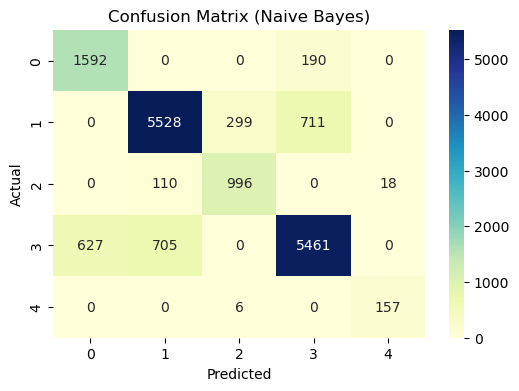

In [61]:
y_pred_nb = nb_model.predict(X_test)

#Evaluate
print("Accuracy (Naive Bayes):", accuracy_score(y_test, y_pred_nb))
print("\nClassification Report:\n", classification_report(y_test, y_pred_nb))

#Confusion Matrix
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_nb), annot=True, fmt="d", cmap="YlGnBu")
plt.title("Confusion Matrix (Naive Bayes)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

DNN

In [62]:
pip install tensorflow

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [63]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import accuracy_score, classification_report
import numpy as np

num_classes = len(set(y_train))
y_train_nn = to_categorical(y_train, num_classes)
y_test_nn = to_categorical(y_test, num_classes)

model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(num_classes, activation='softmax')  # Output layer for classification
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

history = model.fit(
    X_train, y_train_nn,
    validation_data=(X_test, y_test_nn),
    epochs=50,
    batch_size=32,
    verbose=1
)

C:\Users\Lenovo\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
2050/2050 ━━━━━━━━━━━━━━━━━━━━ 16s 6ms/step - accuracy: 0.8538 - loss: 0.3623 - val_accuracy: 0.9565 - val_loss: 0.1290
Epoch 2/50
2050/2050 ━━━━━━━━━━━━━━━━━━━━ 29s 10ms/step - accuracy: 0.9301 - loss: 0.1664 - val_accuracy: 0.9702 - val_loss: 0.0863
Epoch 3/50
2050/2050 ━━━━━━━━━━━━━━━━━━━━ 17s 8ms/step - accuracy: 0.9502 - loss: 0.1188 - val_accuracy: 0.9758 - val_loss: 0.0612
Epoch 4/50
2050/2050 ━━━━━━━━━━━━━━━━━━━━ 26s 11ms/step - accuracy: 0.9591 - loss: 0.0969 - val_accuracy: 0.9760 - val_loss: 0.0542
Epoch 5/50
2050/2050 ━━━━━━━━━━━━━━━━━━━━ 39s 10ms/step - accuracy: 0.9655 - loss: 0.0822 - val_accuracy: 0.9812 - val_loss: 0.0515
Epoch 6/50
2050/2050 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - accuracy: 0.9695 - loss: 0.0730 - val_accuracy: 0.9795 - val_loss: 0.0493
Epoch 7/50
2050/2050 ━━━━━━━━━━━━━━━━━━━━ 26s 12ms/step - accuracy: 0.9707 - loss: 0.0702 - val_accuracy: 0.9748 - val_loss: 0.0485
Epoch 8/50
2050/2050 ━━━━━━━━━━━━━━━━━━━━ 38s 10ms/step - accuracy: 0.9723 - lo

In [64]:
y_pred_nn = model.predict(X_test)
y_pred_labels = np.argmax(y_pred_nn, axis=1)

print("Accuracy (DNN):", accuracy_score(y_test, y_pred_labels))
print("\nClassification Report:\n", classification_report(y_test, y_pred_labels))

513/513 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step
Accuracy (DNN): 0.9890853658536586

Classification Report:
               precision    recall  f1-score   support

           0       0.96      1.00      0.98      1782
           1       1.00      0.99      0.99      6538
           2       0.98      0.97      0.97      1124
           3       0.99      0.99      0.99      6793
           4       0.90      0.93      0.91       163

    accuracy                           0.99     16400
   macro avg       0.97      0.97      0.97     16400
weighted avg       0.99      0.99      0.99     16400



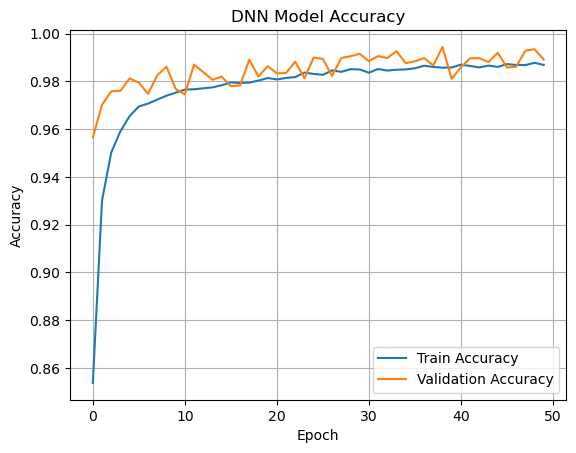

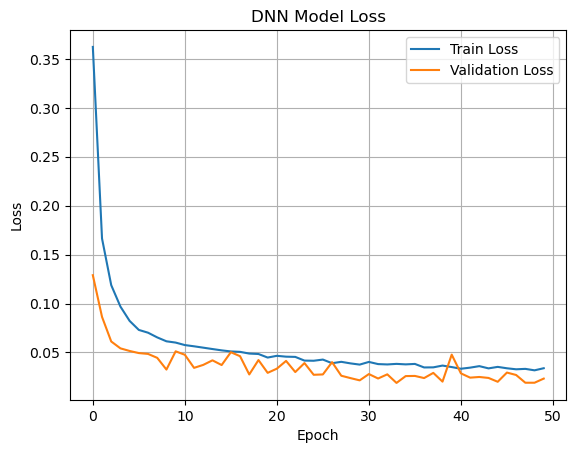

In [65]:
import matplotlib.pyplot as plt

# Accuracy
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title("DNN Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

# Loss
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title("DNN Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()
